<a href="https://colab.research.google.com/github/SophiaPeritz/pinn-turbolence/blob/main/notebooks/train_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Monta Drive per salvare i checkpoint
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_DIR = '/content/drive/MyDrive/pinn-turbulence-results'
os.makedirs(DRIVE_DIR, exist_ok=True)
print(f"Cartella risultati: {DRIVE_DIR}")

# Clona la repo (la prima volta)
!git clone https://github.com/SophiaPeritz/pinn-turbolence.git
%cd pinn-turbolence

Mounted at /content/drive
Cartella risultati: /content/drive/MyDrive/pinn-turbulence-results
Cloning into 'pinn-turbolence'...
remote: Enumerating objects: 64, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 64 (delta 13), reused 64 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (64/64), 3.47 MiB | 8.20 MiB/s, done.
Resolving deltas: 100% (13/13), done.
/content/pinn-turbolence


In [2]:
# Installa dipendenze
!pip install deepxde torch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 11.3 MB/s eta 0:00:00


In [3]:
# Importa i tuoi moduli
import sys
sys.path.append('/content/pinn-turbulence')

In [4]:
# ── CELLA 4: Verifica GPU ─────────────────────────────────────
import torch
print('GPU disponibile:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')
else:
    print('ATTENZIONE: nessuna GPU. Vai su Runtime > Cambia tipo di runtime > T4 GPU')

GPU disponibile: True
GPU: Tesla T4
VRAM: 15.6 GB


[train] Device: cuda
[train] Parametri: 232,195
[train] Inizio training: 20000 iterazioni, Re=1000
  it    500 | loss=5.727e-01 | IC=3.265e-03 | PDE=2.462e-01 | BC=0.000e+00 | lr=9.74e-04
  it   1000 | loss=5.061e-01 | IC=3.191e-03 | PDE=1.870e-01 | BC=0.000e+00 | lr=9.49e-04
  it   1500 | loss=4.907e-01 | IC=3.214e-03 | PDE=1.693e-01 | BC=0.000e+00 | lr=9.24e-04
  it   2000 | loss=1.998e-01 | IC=8.008e-04 | PDE=1.197e-01 | BC=0.000e+00 | lr=9.00e-04
  it   2500 | loss=1.926e-01 | IC=7.422e-04 | PDE=1.183e-01 | BC=0.000e+00 | lr=8.77e-04
  it   3000 | loss=1.667e-01 | IC=7.796e-04 | PDE=8.869e-02 | BC=0.000e+00 | lr=8.54e-04
  it   3500 | loss=2.669e-01 | IC=1.336e-03 | PDE=1.333e-01 | BC=0.000e+00 | lr=8.32e-04
  it   4000 | loss=1.122e-01 | IC=4.882e-04 | PDE=6.339e-02 | BC=0.000e+00 | lr=8.10e-04
  it   4500 | loss=9.626e-02 | IC=3.520e-04 | PDE=6.106e-02 | BC=0.000e+00 | lr=7.89e-04
  it   5000 | loss=1.160e-01 | IC=5.001e-04 | PDE=6.600e-02 | BC=0.000e+00 | lr=7.68e-04
[checkpoint

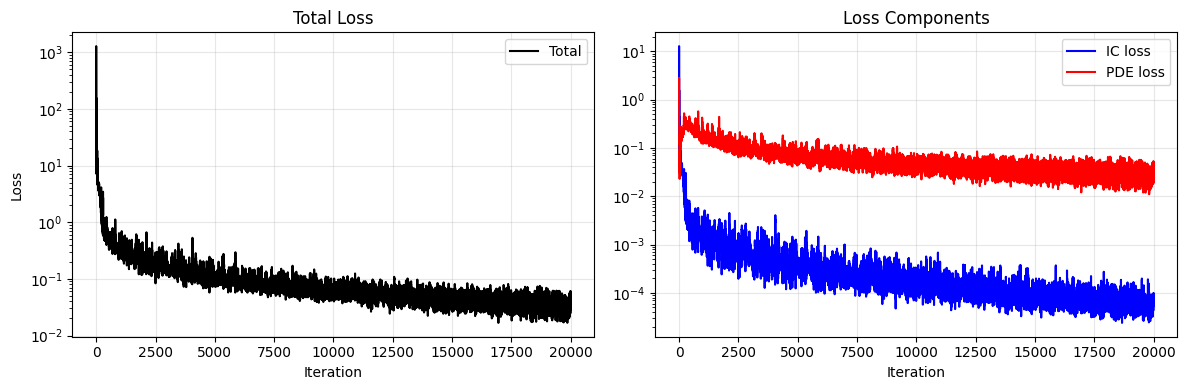

[plot] Salvato: /content/drive/MyDrive/pinn-turbulence-results/baseline_withbc/baseline_velocity.png


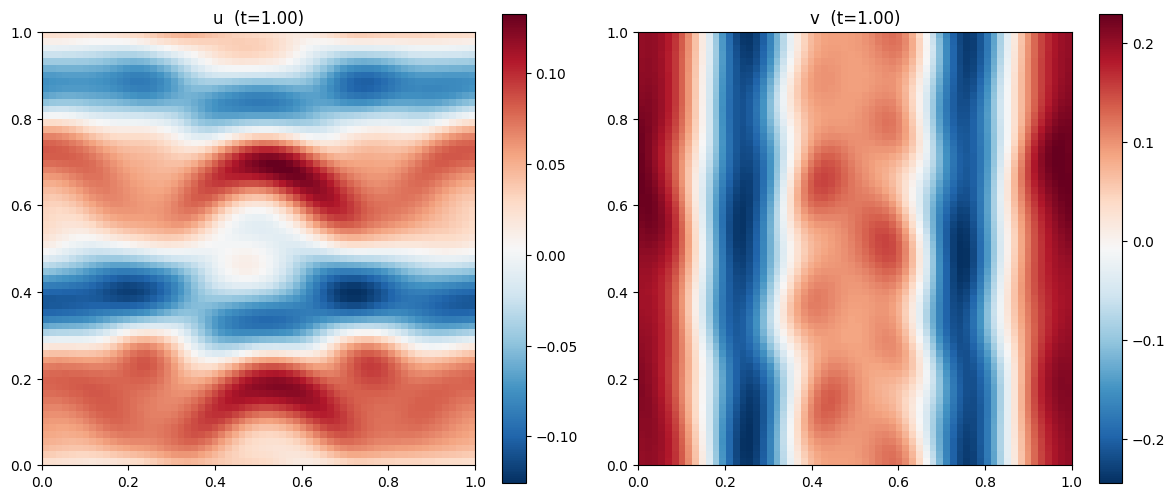

[checkpoint] Salvato: /content/drive/MyDrive/pinn-turbulence-results/baseline_withbc/weights/baseline_final.pt


In [5]:
# ── CELLA 5: Lancia il training ───────────────────────────────
import sys
sys.path.insert(0, '/content/pinn-turbolence')

from src.training import train, load_config

cfg = load_config('configs/kolmogorov.yaml')

# Salva i risultati su Google Drive invece che nella repo
cfg['results_dir'] = DRIVE_DIR + '/baseline_withbc'

model, history = train(cfg, cfg_path='configs/kolmogorov.yaml')

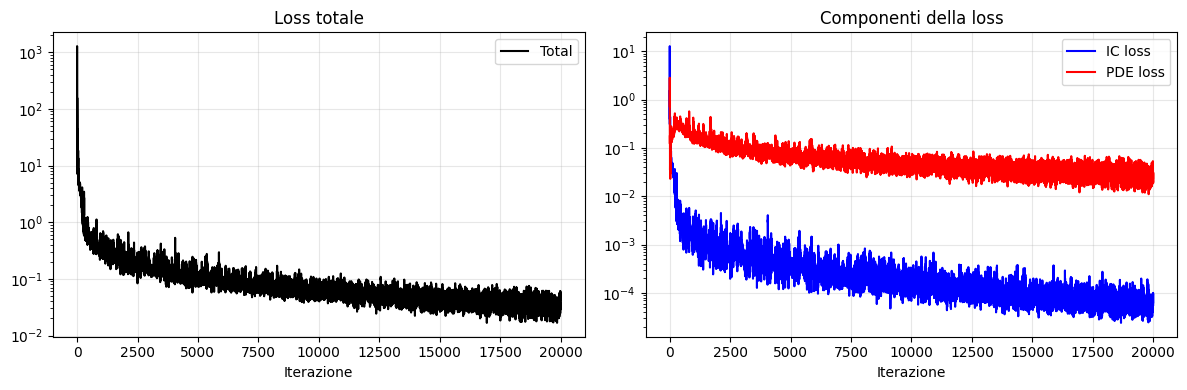

Grafico salvato su Drive.


In [6]:
# ── CELLA 6: Visualizza risultati ────────────────────────────
# (esegui questa cella dopo che il training e' finito)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(history['total'], color='black', label='Total')
axes[0].set_title('Loss totale')
axes[0].set_xlabel('Iterazione')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].semilogy(history['ic'],  color='blue',  label='IC loss')
axes[1].semilogy(history['pde'], color='red',   label='PDE loss')
axes[1].set_title('Componenti della loss')
axes[1].set_xlabel('Iterazione')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig(DRIVE_DIR + '/baseline_loss.png', dpi=150)
plt.show()
print(f"Grafico salvato su Drive.")